In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

In [15]:
df = pd.read_csv("model_training_early_events.csv")

df.head()

,uuid,match_id,puuid,win_label,champion_name,team_position,side,patch,team_first_blood,enemy_first_blood,...,first_dragon_advantage,team_first_grub,enemy_first_grub,first_grub_advantage,team_first_herald,enemy_first_herald,first_herald_advantage,team_first_tower,enemy_first_tower,first_tower_advantage
0,NA1_5551388283_HyV5KTRtWB8THW-426oLBI5qiUhzH0E...,NA1_5551388283,HyV5KTRtWB8THW-426oLBI5qiUhzH0ErInv-1pQUCU5Aka...,0,Ambessa,TOP,blue,16.9.772.1032,0,1,...,1,0,1,-1,1,0,1,0,1,-1
1,NA1_5551055165_HyV5KTRtWB8THW-426oLBI5qiUhzH0E...,NA1_5551055165,HyV5KTRtWB8THW-426oLBI5qiUhzH0ErInv-1pQUCU5Aka...,1,Varus,TOP,red,16.9.772.1032,1,0,...,1,0,1,-1,0,1,-1,1,0,1
2,NA1_5551039061_HyV5KTRtWB8THW-426oLBI5qiUhzH0E...,NA1_5551039061,HyV5KTRtWB8THW-426oLBI5qiUhzH0ErInv-1pQUCU5Aka...,1,Kennen,TOP,red,16.9.772.1032,1,0,...,-1,1,0,1,0,0,0,1,0,1
3,NA1_5551019114_HyV5KTRtWB8THW-426oLBI5qiUhzH0E...,NA1_5551019114,HyV5KTRtWB8THW-426oLBI5qiUhzH0ErInv-1pQUCU5Aka...,1,Vayne,TOP,red,16.9.772.1032,1,0,...,1,1,0,1,1,0,1,1,0,1
4,NA1_5550986486_HyV5KTRtWB8THW-426oLBI5qiUhzH0E...,NA1_5550986486,HyV5KTRtWB8THW-426oLBI5qiUhzH0ErInv-1pQUCU5Aka...,0,Anivia,TOP,blue,16.9.772.1032,1,0,...,-1,0,1,-1,1,0,1,1,0,1


In [16]:
print(df.shape)
print(df.columns)
print(df.isna().sum())
print(df["win_label"].value_counts(normalize=True))

(6196, 23)
Index(['uuid', 'match_id', 'puuid', 'win_label', 'champion_name',
       'team_position', 'side', 'patch', 'team_first_blood',
       'enemy_first_blood', 'first_blood_advantage', 'team_first_dragon',
       'enemy_first_dragon', 'first_dragon_advantage', 'team_first_grub',
       'enemy_first_grub', 'first_grub_advantage', 'team_first_herald',
       'enemy_first_herald', 'first_herald_advantage', 'team_first_tower',
       'enemy_first_tower', 'first_tower_advantage'],
      dtype='str')
uuid                      0
match_id                  0
puuid                     0
win_label                 0
champion_name             0
team_position             0
side                      0
patch                     0
team_first_blood          0
enemy_first_blood         0
first_blood_advantage     0
team_first_dragon         0
enemy_first_dragon        0
first_dragon_advantage    0
team_first_grub           0
enemy_first_grub          0
first_grub_advantage      0
team_first_herald 

In [28]:
target = "win_label"

drop_cols = [
    "uuid",      # row-level ID, not useful for prediction
    "match_id",  # used for grouped splitting, not as a model feature
    "puuid",     # player ID, can cause memorization/leakage
    "win_label"  # target column
]

X = df.drop(columns=drop_cols)
y = df[target]

groups = df["match_id"]  # used to keep rows from the same match together

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (6196, 19)
y shape: (6196,)


,champion_name,team_position,side,patch,team_first_blood,enemy_first_blood,first_blood_advantage,team_first_dragon,enemy_first_dragon,first_dragon_advantage,team_first_grub,enemy_first_grub,first_grub_advantage,team_first_herald,enemy_first_herald,first_herald_advantage,team_first_tower,enemy_first_tower,first_tower_advantage
0,Ambessa,TOP,blue,16.9.772.1032,0,1,-1,1,0,1,0,1,-1,1,0,1,0,1,-1
1,Varus,TOP,red,16.9.772.1032,1,0,1,1,0,1,0,1,-1,0,1,-1,1,0,1
2,Kennen,TOP,red,16.9.772.1032,1,0,1,0,1,-1,1,0,1,0,0,0,1,0,1
3,Vayne,TOP,red,16.9.772.1032,1,0,1,1,0,1,1,0,1,1,0,1,1,0,1
4,Anivia,TOP,blue,16.9.772.1032,1,0,1,0,1,-1,0,1,-1,1,0,1,1,0,1


In [ ]:
# First split: train+validation vs test
# GroupShuffleSplit splits the data while keeping the same match together.
# n_splits=1 means we only want one split (one train+val set and one test set).
# test_size=0.2 means 20% of the matches will be in the test set, and 80% in train+validation.
# random_state=42 ensures that the split is reproducible (the same every time you run the code).
gss_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_val_idx, test_idx = next(
    gss_test.split(X, y, groups=groups)
)

X_train_val = X.iloc[train_val_idx]
X_test = X.iloc[test_idx]

y_train_val = y.iloc[train_val_idx]
y_test = y.iloc[test_idx]

groups_train_val = groups.iloc[train_val_idx]
groups_test = groups.iloc[test_idx]

In [30]:
# Second split: train vs validation

gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, val_idx = next(
    gss_val.split(X_train_val, y_train_val, groups=groups_train_val)
)

X_train = X_train_val.iloc[train_idx]
X_val = X_train_val.iloc[val_idx]

y_train = y_train_val.iloc[train_idx]
y_val = y_train_val.iloc[val_idx]

groups_train = groups_train_val.iloc[train_idx]
groups_val = groups_train_val.iloc[val_idx]

In [31]:
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

print("\nTrain win rate:")
print(y_train.value_counts(normalize=True))

print("\nValidation win rate:")
print(y_val.value_counts(normalize=True))

print("\nTest win rate:")
print(y_test.value_counts(normalize=True))

train_match_ids = set(groups_train)
val_match_ids = set(groups_val)
test_match_ids = set(groups_test)

print("\nMatch ID overlap checks:")
print("Train ∩ Validation:", len(train_match_ids & val_match_ids))
print("Train ∩ Test:", len(train_match_ids & test_match_ids))
print("Validation ∩ Test:", len(val_match_ids & test_match_ids))

Training set: (3982, 19)
Validation set: (967, 19)
Test set: (1247, 19)

Train win rate:
win_label
1    0.618785
0    0.381215
Name: proportion, dtype: float64

Validation win rate:
win_label
1    0.622544
0    0.377456
Name: proportion, dtype: float64

Test win rate:
win_label
1    0.608661
0    0.391339
Name: proportion, dtype: float64

Match ID overlap checks:
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [32]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numeric_cols = X_train.select_dtypes(exclude="object").columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Categorical columns: ['champion_name', 'team_position', 'side', 'patch']
Numeric columns: ['team_first_blood', 'enemy_first_blood', 'first_blood_advantage', 'team_first_dragon', 'enemy_first_dragon', 'first_dragon_advantage', 'team_first_grub', 'enemy_first_grub', 'first_grub_advantage', 'team_first_herald', 'enemy_first_herald', 'first_herald_advantage', 'team_first_tower', 'enemy_first_tower', 'first_tower_advantage']


C:\Users\alanl\AppData\Local\Temp\ipykernel_4508\631095678.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include="object").columns.tolist()


In [33]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

In [34]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    min_samples_leaf=3,
    n_jobs=-1
)

In [35]:
model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("random_forest", rf_model)
    ]
)

In [36]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('random_forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [37]:
y_val_pred = model.predict(X_val)
y_val_prob = model.predict_proba(X_val)[:, 1]

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation ROC-AUC:", roc_auc_score(y_val, y_val_prob))

print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred))


Validation Accuracy: 0.6804550155118925
Validation ROC-AUC: 0.7337937468711602

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.66      0.61       365
           1       0.77      0.69      0.73       602

    accuracy                           0.68       967
   macro avg       0.67      0.68      0.67       967
weighted avg       0.69      0.68      0.68       967



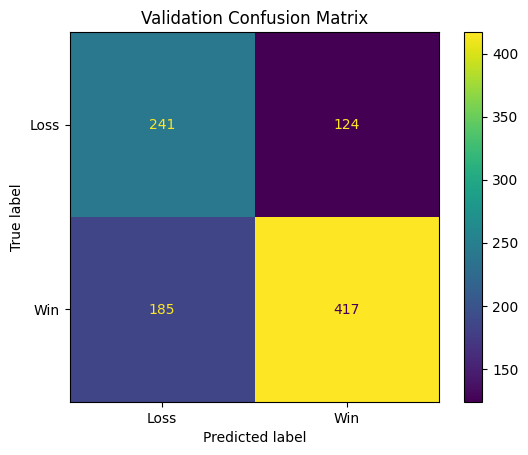

In [38]:
cm_val = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_val,
    display_labels=["Loss", "Win"]
)

disp.plot()
plt.title("Validation Confusion Matrix")
plt.show()

In [39]:
y_test_pred = model.predict(X_test)
y_test_prob = model.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_prob))

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.7273456295108259
Test ROC-AUC: 0.7983838743817361

Test Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.73      0.68       488
           1       0.81      0.73      0.76       759

    accuracy                           0.73      1247
   macro avg       0.72      0.73      0.72      1247
weighted avg       0.74      0.73      0.73      1247



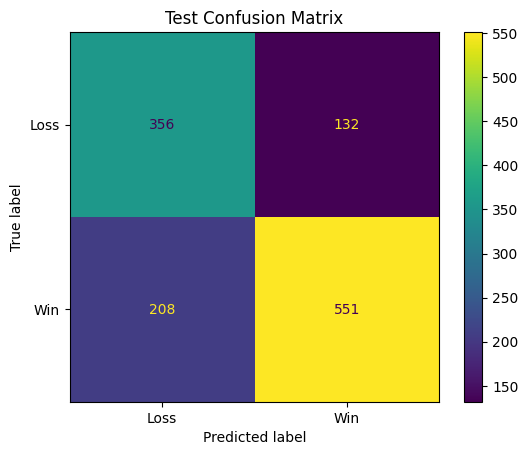

In [40]:
cm_test = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=["Loss", "Win"]
)

disp.plot()
plt.title("Test Confusion Matrix")
plt.show()

In [41]:
baseline_accuracy = y_test.value_counts(normalize=True).max()
model_accuracy = accuracy_score(y_test, y_test_pred)

print("Baseline accuracy from always predicting the majority class:", baseline_accuracy)
print("Random Forest test accuracy:", model_accuracy)
print("Improvement over baseline:", model_accuracy - baseline_accuracy)

Baseline accuracy from always predicting the majority class: 0.6086607858861267
Random Forest test accuracy: 0.7273456295108259
Improvement over baseline: 0.11868484362469922


In [43]:
# Get OneHotEncoder from the fitted pipeline
ohe = model.named_steps["preprocess"].named_transformers_["cat"]

# Get encoded categorical feature names
cat_feature_names = ohe.get_feature_names_out(categorical_cols)

# Combine encoded categorical feature names and numeric feature names
feature_names = list(cat_feature_names) + numeric_cols

# Get Random Forest feature importance values
importances = model.named_steps["random_forest"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importance_df.head(20)

,feature,importance
197,first_tower_advantage,0.160360
195,team_first_tower,0.128163
196,enemy_first_tower,0.116107
194,first_herald_advantage,0.077201
192,team_first_herald,0.065788
193,enemy_first_herald,0.056668
186,team_first_dragon,0.032231
188,first_dragon_advantage,0.029716
187,enemy_first_dragon,0.028809
174,side_blue,0.016352


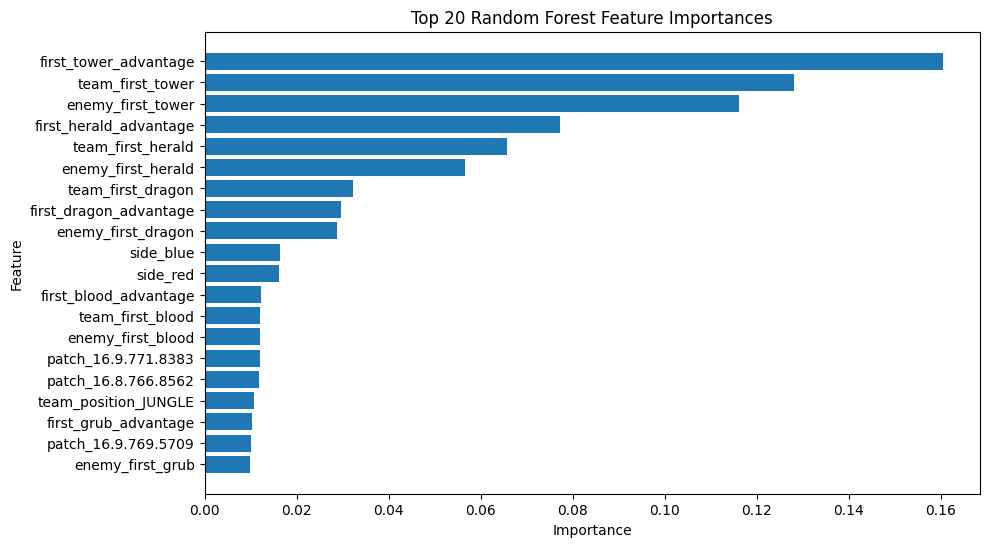

In [44]:
top_features = feature_importance_df.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Random Forest Feature Importances")
plt.show()